In [1]:
from pathlib import Path
import sys
ROOT = Path.cwd().resolve()
CANDIDATES = [ROOT] + list(ROOT.parents)
PROJECT_ROOT = next((p for p in CANDIDATES if (p / 'src').exists()), ROOT)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

# 05 Evaluation Report
Tong hop ket qua, metric va insight theo regime.

In [2]:
import pandas as pd
tables = PROJECT_ROOT / 'outputs' / 'tables'
forecast_metrics = pd.read_csv(tables / 'forecast_metrics.csv') if (tables / 'forecast_metrics.csv').exists() else pd.DataFrame()
cls_metrics = pd.read_csv(tables / 'classification_metrics.csv') if (tables / 'classification_metrics.csv').exists() else pd.DataFrame()
rules = pd.read_csv(tables / 'top_association_rules.csv') if (tables / 'top_association_rules.csv').exists() else pd.DataFrame()
forecast_metrics

,model,mae,rmse
0,Naive,681.970112,1215.254253
1,ETS,687.649441,1216.028602
2,ARIMA,700.013017,1230.254675


In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

palette = {"stormcloud": "#4F6367", "beige": "#EEF5DB", "sunset": "#FE5F55"}
sns.set_theme(style="whitegrid")

In [4]:
rules.head(10) if len(rules) > 0 else rules

,antecedents,consequents,support,confidence,lift,leverage,conviction
0,"Litecoin__down__high_vol, Tron__down__high_vol",EOS__down__high_vol,0.082432,0.859155,4.957307,0.065804,5.869493
1,"Stellar__down__high_vol, Tron__down__high_vol",Cardano__down__high_vol,0.084122,0.824503,4.871317,0.066853,4.733669
2,"Iota__down__high_vol, Litecoin__down__high_vol",EOS__down__high_vol,0.089865,0.841772,4.857009,0.071363,5.224676
3,"ChainLink__down__high_vol, Stellar__down__high...",Cardano__down__high_vol,0.084797,0.820261,4.846255,0.067300,4.621953
4,"Stellar__up__high_vol, Tron__up__high_vol",EOS__up__high_vol,0.083446,0.845890,4.843009,0.066216,5.355526
5,"Cardano__up__high_vol, EOS__up__high_vol",Tron__up__high_vol,0.089189,0.776471,4.788235,0.070562,3.748222
6,Tron__up__high_vol,"Cardano__up__high_vol, EOS__up__high_vol",0.089189,0.550000,4.788235,0.070562,1.966967
7,"EOS__up__high_vol, Stellar__up__high_vol",Tron__up__high_vol,0.083446,0.774295,4.774817,0.065970,3.712087
8,"Litecoin__up__high_vol, Tron__up__high_vol",EOS__up__high_vol,0.084797,0.833887,4.774286,0.067036,4.968534
9,"EOS__up__high_vol, NEM__up__high_vol",Tron__up__high_vol,0.080405,0.767742,4.734409,0.063422,3.607357


In [5]:
if len(forecast_metrics) > 0:
    rank = forecast_metrics.sort_values("rmse").reset_index(drop=True)
else:
    rank = forecast_metrics
rank

,model,mae,rmse
0,Naive,681.970112,1215.254253
1,ETS,687.649441,1216.028602
2,ARIMA,700.013017,1230.254675


In [6]:
cls_path = tables / "classification_metrics.csv"
shock_path = tables / "classification_error_shock.csv"
cls_pred_path = tables / "classification_predictions.csv"
cls_df = pd.read_csv(cls_path) if cls_path.exists() else pd.DataFrame()
shock_df = pd.read_csv(shock_path) if shock_path.exists() else pd.DataFrame()
pred_df = pd.read_csv(cls_pred_path) if cls_pred_path.exists() else pd.DataFrame()
cls_df

,metric,value
0,accuracy,1.00000
1,f1,1.00000
2,roc_auc,1.00000
3,train_seconds,13.66379
4,n_train,28833.00000
5,n_test,7209.00000


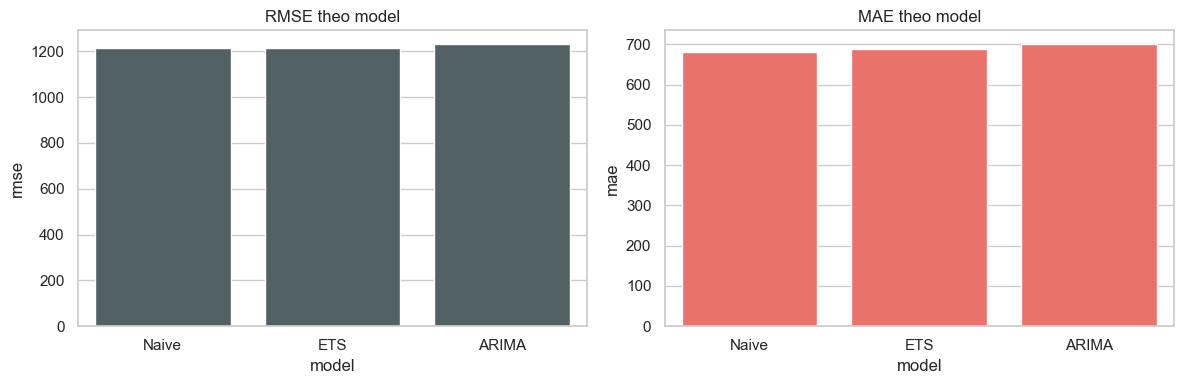

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
if len(rank) > 0:
    sns.barplot(data=rank, x="model", y="rmse", color=palette["stormcloud"], ax=axes[0])
    sns.barplot(data=rank, x="model", y="mae", color=palette["sunset"], ax=axes[1])
axes[0].set_title("RMSE theo model")
axes[1].set_title("MAE theo model")
plt.tight_layout()
plt.show()